# initialize

In [ ]:
import os
import sys
from pathlib import Path
import joblib
import numexpr
numexpr.set_num_threads(64)
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)
project_root = Path.cwd().parent
print(project_root)
sys.path.insert(0, str(project_root))
from src.Bayesian import *
from src.Bayesian.problems.config import config_fgt
from src.Bayesian.problems import *
from src.Bayesian.utils.optimizer import Optimizer, ConstantDict
from src.Bayesian.utils.model_evaluation import ModelEval
from src.Bayesian.problems.fit_config import window_size_configs
model_name = 'M6_MH'
# 导入模型配置
from src.Bayesian.problems.fit_config import window_size_configs
if model_name == 'M0_Base':
    module_configs = {}
elif model_name == 'M1_P':
    module_configs = {"perception": (BasePerception, {})}
elif model_name == 'M2_M':
    module_configs = {"memory": (BaseMemory, {
                        "personal_memory_range": {
                            "gamma": (0.05, 1.0),
                            "w0": (0.075, 0.15)
                        },
                        "param_resolution": 20
                    })}  
elif model_name == 'M3_H':
    from src.Bayesian.problems.fit_config import module_configs_M3
    module_configs = module_configs_M3
elif model_name == 'M4_PM':
    module_configs = {
            "memory": (BaseMemory, {
                "personal_memory_range": {
                    "gamma": (0.05, 1.0),
                    "w0": (0.075, 0.15)
                },
                "param_resolution": 20
            }),
            "perception": (BasePerception, {})}    
elif model_name == 'M5_PH':
    from src.Bayesian.problems.fit_config import module_configs_M5
    module_configs = module_configs_M5
elif model_name == 'M6_MH':
    from src.Bayesian.problems.fit_config import module_configs_M6
    module_configs = module_configs_M6
elif model_name == 'M7_PMH':
    from src.Bayesian.problems.fit_config import module_configs_M7
    module_configs = module_configs_M7
# 初始化优化器
optimizer = Optimizer(module_configs, n_jobs=120)
# 导入数据
processed_path = Path(project_root) / 'data_meg' / 'processed'/'Task3b'/ 'Task3b_processed.csv'
optimizer.prepare_data(processed_path)
subIDs = [333]
result_path = Path(project_root) / 'results' / 'Model_results_sub333_260324_focal' 

/home/yangjiong/CategoryLearning_gitcode
Using parallel optimization for multiple subjects.


# model:M6

In [ ]:
# 执行优化
subIDs = [333]

result_path = Path(project_root) / 'results' / 'Model_results_sub333_260324_focal' 
os.makedirs(result_path, exist_ok=True)
if model_name == 'M0_Base':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 1, 0)

elif model_name == 'M1_P':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 0, 500)
    
elif model_name == 'M2_M':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 1, 0)
    
elif model_name == 'M3_H':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 0, 1000)
    
elif model_name == 'M4_PM':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 3, 500)
    
elif model_name == 'M5_PH':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 0, 1000)
    
elif model_name == 'M6_MH': 
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 50, 1000)

elif model_name == 'M7_PMH':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 5, 1000)
    
    
# 保存优化结果
optimizer.save_results(res, model_name, result_path)

Processing tasks:   0%|                                                     | 0/400 [00:00<?, ?it/s]

/home/yangjiong/CategoryLearning_gitcode/logs/Run_20260323_163702.log


INFO:cat-learning:logger is running normally.


{'default_model': {'modules': {}, 'agenda': ['__self__']}, 'm_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'increase_rate': 1.15, 'decrease_rate': 0.3}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}, 'memory_mod': {'class': 'src.Bayesian_state.problems.modules.memory.DualMemoryModule', 'kwargs': {'w0': 0.8, 'gamma': 0.8}}}, 'agenda': ['likelihood_mod', 'memory_mod', 'beta_mod']}, 'base_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'decrease_rate': 0.5, 'correct_additive': 2.0, 'use_prior_scaling': True, 'prior_beta_scale': 10.0}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}}, 'agenda': ['likelihood_mod', '__self__', 'beta_mod']}

Processing tasks:  30%|████████████▉                              | 120/400 [00:04<00:10, 25.88it/s]INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.


...

INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is runnin

{'default_model': {'modules': {}, 'agenda': ['__self__']}, 'm_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'increase_rate': 1.15, 'decrease_rate': 0.3}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}, 'memory_mod': {'class': 'src.Bayesian_state.problems.modules.memory.DualMemoryModule', 'kwargs': {'w0': 0.8, 'gamma': 0.8}}}, 'agenda': ['likelihood_mod', 'memory_mod', 'beta_mod']}, 'base_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'decrease_rate': 0.5, 'correct_additive': 2.0, 'use_prior_scaling': True, 'prior_beta_scale': 10.0}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}}, 'agenda': ['likelihood_mod', '__self__', 'beta_mod']}

INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.


/home/yangjiong/CategoryLearning_gitcode/logs/Run_20260323_173435.log
{'default_model': {'modules': {}, 'agenda': ['__self__']}, 'm_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'increase_rate': 1.15, 'decrease_rate': 0.3}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}, 'memory_mod': {'class': 'src.Bayesian_state.problems.modules.memory.DualMemoryModule', 'kwargs': {'w0': 0.8, 'gamma': 0.8}}}, 'agenda': ['likelihood_mod', 'memory_mod', 'beta_mod']}, 'base_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'decrease_rate': 0.5, 'correct_additive': 2.0, 'use_prior_scaling': True, 'prior_beta_scale': 10.0}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule',

Computing error for params: 100%|██████████| 1000/1000 [02:48<00:00,  5.94it/s]
2026-03-23 17:38:26 - INFO - Results saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260322/M6_MH.joblib


# prediction model

In [8]:
res = joblib.load(result_path / f'{model_name}.joblib')
# 计算预测结果
import random
import os
import numpy as np

optimizer.set_results(res)
prediction = optimizer.predict_probs_with_subs_parallel(
    config_fgt, subIDs)
joblib.dump(prediction, result_path / f'{model_name}_predict_probs.joblib')

Predicting tasks: 100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 1215.39it/s]


/home/yangjiong/CategoryLearning_gitcode/logs/Run_20260324_181904.log
{'default_model': {'modules': {}, 'agenda': ['__self__']}, 'm_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'increase_rate': 1.15, 'decrease_rate': 0.3}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}, 'memory_mod': {'class': 'src.Bayesian_state.problems.modules.memory.DualMemoryModule', 'kwargs': {'w0': 0.8, 'gamma': 0.8}}}, 'agenda': ['likelihood_mod', 'memory_mod', 'beta_mod']}, 'base_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'decrease_rate': 0.5, 'correct_additive': 2.0, 'use_prior_scaling': True, 'prior_beta_scale': 10.0}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule',

INFO:cat-learning:logger is running normally.


['/home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260322/M6_MH_predict_probs.joblib']

In [9]:
prediction

{333: {'condition': 3,
  'true_choice': array([1, 2, 2, 3, 2, 4, 2, 3, 2, 4, 3, 1, 1, 2, 3, 1, 3, 1, 1, 3, 1, 1,
         4, 2, 1, 1, 4, 1, 1, 4, 3, 4, 4, 2, 2, 2, 4, 1, 4, 2, 2, 1, 4, 1,
         4, 2, 2, 3, 3, 1, 3, 1, 4, 2, 2, 3, 4, 3, 1, 2, 3, 1, 4, 1, 4, 3,
         2, 2, 1, 1, 3, 2, 3, 1, 2, 3, 3, 3, 1, 1, 2, 4, 3, 3, 2, 3, 4, 3,
         2, 2, 4, 3, 2, 1, 3, 1, 3, 2, 2, 3, 4, 3, 2, 4, 2, 1, 3, 1, 2, 4,
         2, 3, 1, 3, 3, 4, 1, 2, 2, 4, 3, 2, 1, 1, 2, 1, 3, 1, 1, 2, 2, 2,
         1, 2, 1, 3, 4, 2, 2, 2, 3, 3, 3, 3, 2, 3, 4, 3, 2, 3, 3, 3, 1, 2,
         4, 2, 4, 3, 1, 1, 2, 3, 2, 2, 2, 3, 2, 1, 3, 3, 4, 2, 1, 2, 4, 3,
         2, 3, 2, 4, 1, 3, 3, 1, 4, 3, 3, 2, 1, 4, 1, 3, 3, 3, 3, 2, 1, 1,
         4, 3, 3, 3, 4, 3, 3, 2, 3, 4, 4, 4, 2, 4, 1, 3, 3, 2, 3, 4, 1, 2,
         4, 2, 3, 3, 4, 3, 2, 3, 2, 2, 1, 3, 2, 4, 3, 3, 4, 4, 3, 3, 3, 2,
         1, 2, 4, 1, 1, 3, 2, 3, 2, 4, 1, 3, 2, 3, 1, 2, 1, 3, 2, 2, 4, 4,
         4, 3, 4, 4, 2, 4, 4, 3, 4, 2, 1, 4, 3, 3, 2, 3, 3, 1,

# NEW

## Cell 1: hit 序列

✅ After cleaning:
n_trials: 359
choice unique: [1 2 3 4]
pred_choice unique: [1 2 3 4]
rating unique: [1. 2. 3. 4. 5.]
true_acc unique: [0. 1.]


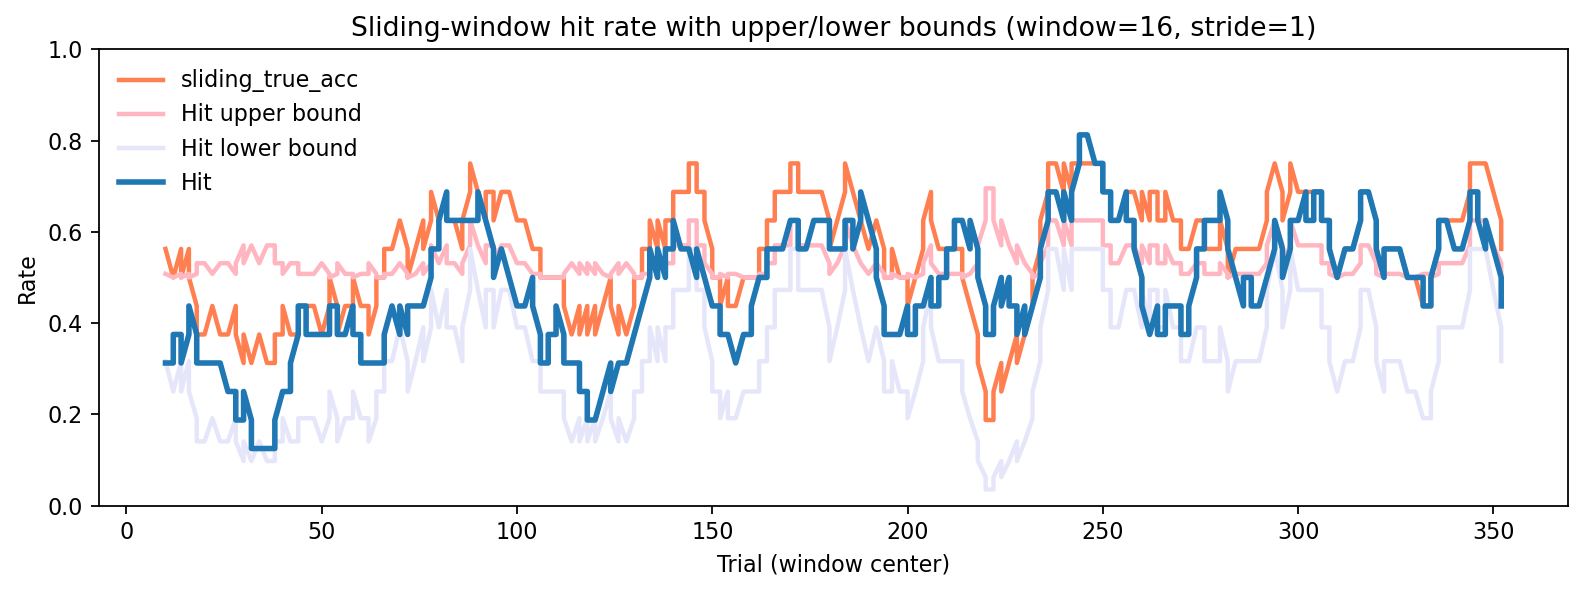

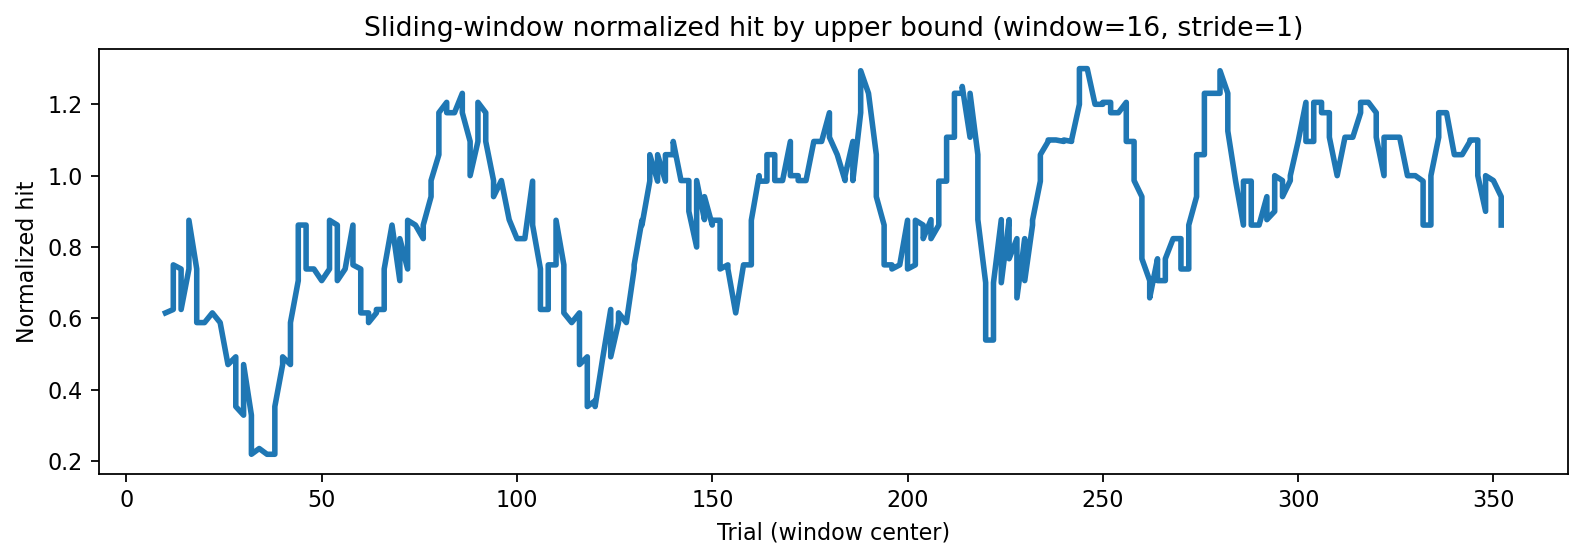

In [20]:
# Cell 1: hit 序列 + 滑窗平均曲线（window=16）
# 新增：
# 1) 添加 hit 上界 / 下界
# 2) 绘制按 hit 上界标准化后的 hit 曲线

import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(processed_path)
rating = df['rating']
choice = df['choice']
probs = prediction[333]['pred_probs']
pred_choice = prediction[333]['pred_choice']
true_acc = prediction[333]['true_acc']   # 逐 trial 的 true_acc（0/1）

rating_np = np.asarray(rating)
choice_np = np.asarray(choice)
pred_np = np.asarray(pred_choice)
probs_np = np.asarray(probs, dtype=float)
true_acc_np = np.asarray(true_acc, dtype=float)

assert len(choice_np) == len(pred_np) == probs_np.shape[0] == len(true_acc_np), \
    f"Length mismatch: choice={len(choice_np)}, pred_choice={len(pred_np)}, probs={probs_np.shape}, true_acc={len(true_acc_np)}"
assert probs_np.shape[1] == 4, f"probs should be (n_trials, 4), got {probs_np.shape}"

# 去掉第1个 trial
choice_np    = choice_np[1:]
pred_np      = pred_np[1:]
rating_np    = rating_np[1:]
probs_np     = probs_np[1:, :]
true_acc_np  = true_acc_np[1:]

trial_id = np.arange(2, 2 + len(choice_np))

valid = np.isfinite(rating_np)
valid &= np.isin(choice_np, [1, 2, 3, 4])
valid &= np.isin(pred_np, [1, 2, 3, 4])
valid &= np.all(np.isfinite(probs_np), axis=1)
valid &= np.isfinite(true_acc_np)
valid &= np.isin(true_acc_np, [0, 1])

choice_c    = choice_np[valid].astype(int)
pred_c      = pred_np[valid].astype(int)
rating_c    = rating_np[valid].astype(float)
probs_c     = probs_np[valid]
true_acc_c  = true_acc_np[valid].astype(float)
trial_c     = trial_id[valid]

print("✅ After cleaning:")
print("n_trials:", len(choice_c))
print("choice unique:", np.unique(choice_c))
print("pred_choice unique:", np.unique(pred_c))
print("rating unique:", np.unique(rating_c))
print("true_acc unique:", np.unique(true_acc_c))

# 1) hit 序列：相同=1，不同=0 
hit = (choice_c == pred_c).astype(float)

# ====== 滑窗平均 ======
def moving_average(x, window=16, stride=1, center=True):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < window:
        raise ValueError(f"n={n} < window={window}")
    starts = np.arange(0, n - window + 1, stride)
    avgs = np.array([x[s:s+window].mean() for s in starts])
    pos = starts + (window - 1) / 2 if center else starts + (window - 1)
    return pos, avgs

window = 16
stride = 1

# hit 的滑窗平均
xpos, hit_ma = moving_average(hit, window=window, stride=stride, center=True)

# true_acc 的滑窗平均 -> sliding_true_acc
_, sliding_true_acc = moving_average(true_acc_c, window=window, stride=stride, center=True)

# 映射到原始 trial 编号（窗口中心）
center_trial = trial_c[np.round(xpos).astype(int)]

# ====== 2) 计算 hit 上界 / 下界 ======
hit_upper = sliding_true_acc**2 + (1 - sliding_true_acc)**2
hit_lower = sliding_true_acc**2

# ====== 3) 画图 ======
plt.figure(figsize=(10, 3.8), dpi=160)
plt.plot(center_trial, sliding_true_acc, linewidth=2, linestyle='-', label='sliding_true_acc',color = 'coral')
plt.plot(center_trial, hit_upper, linewidth=2, linestyle='-', label='Hit upper bound', color = 'lightpink')
plt.plot(center_trial, hit_lower, linewidth=2, linestyle='-', label='Hit lower bound', color = 'lavender')
plt.plot(center_trial, hit_ma, linewidth=2.5, label='Hit')

plt.ylim(0, 1)
plt.xlabel("Trial (window center)")
plt.ylabel("Rate")
plt.title(f"Sliding-window hit rate with upper/lower bounds (window={window}, stride={stride})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ====== 4) 按 hit 上界标准化 ======
# 为避免极端情况下分母为0，做一个很小的保护
eps = 1e-12
hit_norm = hit_ma / np.maximum(hit_upper, eps)

plt.figure(figsize=(10, 3.6), dpi=160)
plt.plot(center_trial, hit_norm, linewidth=2.5)
plt.xlabel("Trial (window center)")
plt.ylabel("Normalized hit")
plt.title(f"Sliding-window normalized hit by upper bound (window={window}, stride={stride})")
plt.tight_layout()
plt.show()

## Cell 2: 在 all / hit / not hit 三种条件下评估 7 个 conf 指标

Condition: all
n_trials: 359 / 359

Results for condition = all (rounded to 4 decimals):


,condition,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,rating_levels_used,n_trials
metric,,,,,,,,,
p_star,all,0.2111,0.0001,0.1595,0.0001,0.5962,1.2907,"[1, 2, 3, 4, 5]",359
composite,all,0.2052,0.0001,0.1559,0.0001,0.5940,1.2855,"[1, 2, 3, 4, 5]",359
log_margin,all,0.1899,0.0003,0.1444,0.0003,0.5871,1.2892,"[1, 2, 3, 4, 5]",359
margin,all,0.1842,0.0005,0.1399,0.0005,0.5843,1.2968,"[1, 2, 3, 4, 5]",359
entropy_conf,all,0.1787,0.0007,0.1326,0.0009,0.5800,1.2982,"[1, 2, 3, 4, 5]",359
top1,all,0.1579,0.0027,0.1168,0.0036,0.5704,1.3068,"[1, 2, 3, 4, 5]",359
top1_margin,all,0.1352,0.0103,0.0999,0.0128,0.5602,1.3073,"[1, 2, 3, 4, 5]",359


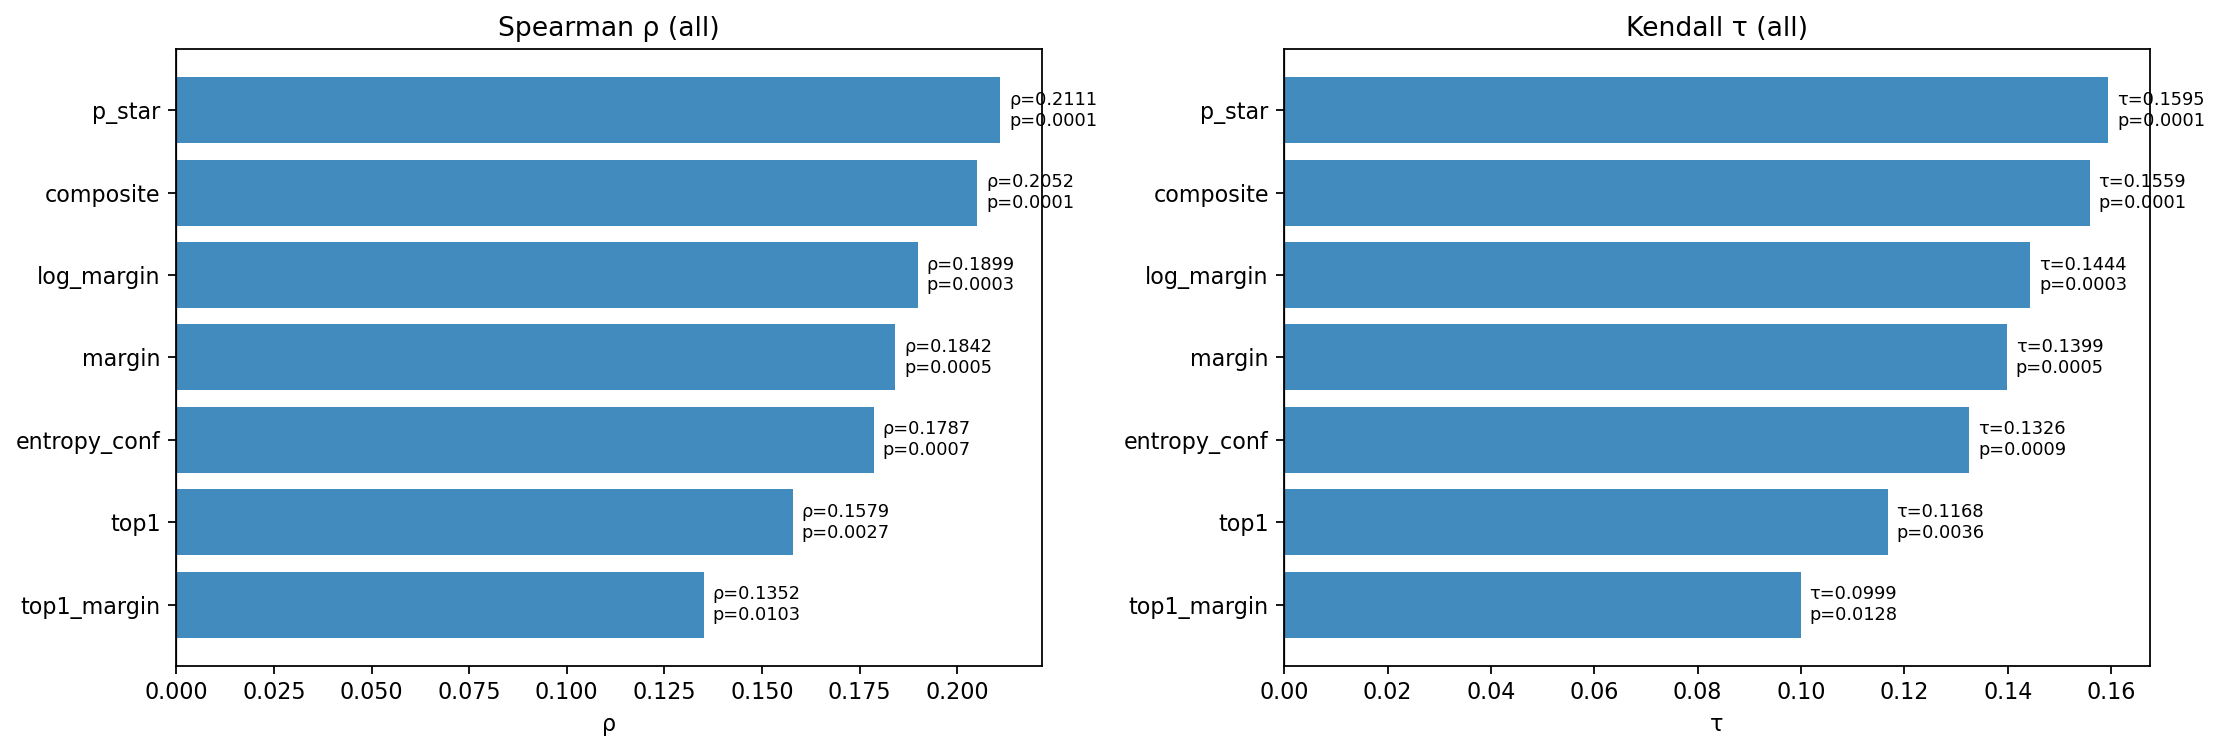

Condition: hit
n_trials: 171 / 359

Results for condition = hit (rounded to 4 decimals):


,condition,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,rating_levels_used,n_trials
metric,,,,,,,,,
entropy_conf,hit,0.2738,0.0003,0.1993,0.0006,0.6175,1.3598,"[1, 2, 3, 4, 5]",171
p_star,hit,0.2680,0.0004,0.1959,0.0007,0.6155,1.3697,"[1, 2, 3, 4, 5]",171
top1,hit,0.2680,0.0004,0.1959,0.0007,0.6155,1.3697,"[1, 2, 3, 4, 5]",171
margin,hit,0.2646,0.0005,0.1958,0.0007,0.6154,1.3675,"[1, 2, 3, 4, 5]",171
top1_margin,hit,0.2646,0.0005,0.1958,0.0007,0.6154,1.3675,"[1, 2, 3, 4, 5]",171
log_margin,hit,0.2599,0.0006,0.1946,0.0008,0.6148,1.3587,"[1, 2, 3, 4, 5]",171
composite,hit,0.2598,0.0006,0.1933,0.0008,0.6140,1.3580,"[1, 2, 3, 4, 5]",171


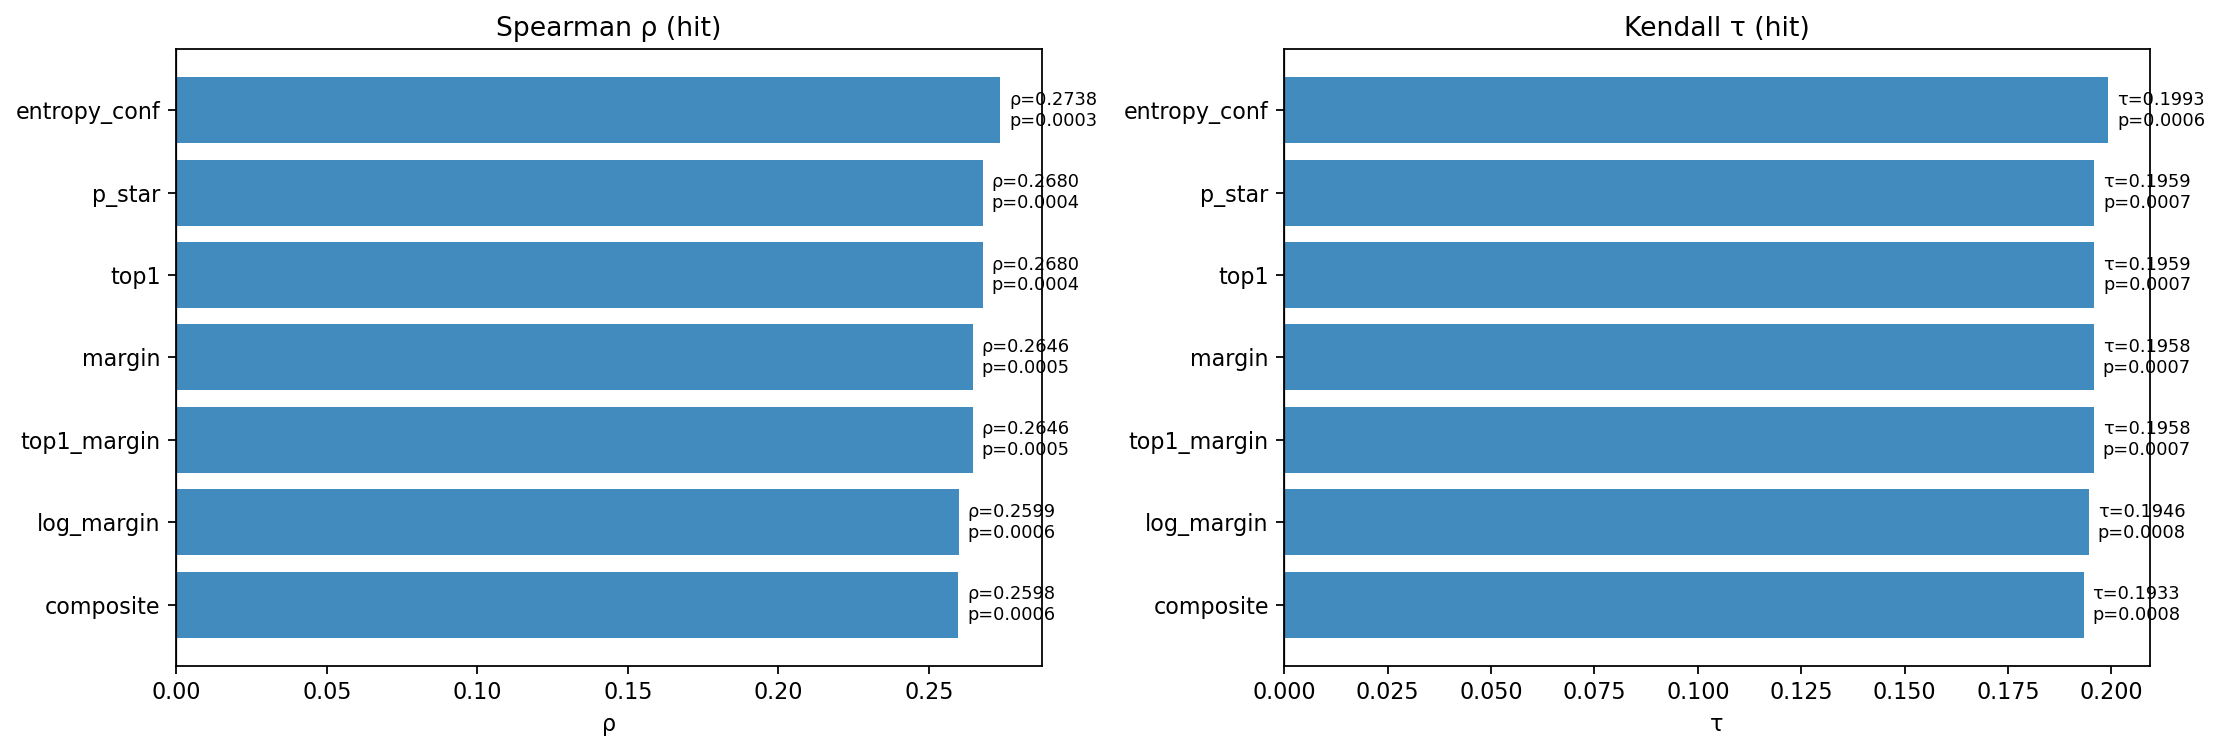

Condition: not_hit
n_trials: 188 / 359

Results for condition = not_hit (rounded to 4 decimals):


,condition,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,rating_levels_used,n_trials
metric,,,,,,,,,
composite,not_hit,0.1382,0.0585,0.1069,0.0573,0.5660,1.2386,"[1, 2, 3, 4, 5]",188
p_star,not_hit,0.1324,0.0701,0.1025,0.0682,0.5633,1.2332,"[1, 2, 3, 4, 5]",188
log_margin,not_hit,0.0984,0.1790,0.0757,0.1783,0.5467,1.2422,"[1, 2, 3, 4, 5]",188
margin,not_hit,0.0736,0.3156,0.0577,0.3048,0.5356,1.2481,"[1, 2, 3, 4, 5]",188
entropy_conf,not_hit,0.0569,0.4383,0.0414,0.4616,0.5255,1.2486,"[1, 2, 3, 4, 5]",188
top1,not_hit,0.0104,0.8874,0.0067,0.9055,0.5041,1.2504,"[1, 2, 3, 4, 5]",188
top1_margin,not_hit,-0.0452,0.5382,-0.0360,0.5214,0.4777,1.2483,"[1, 2, 3, 4, 5]",188


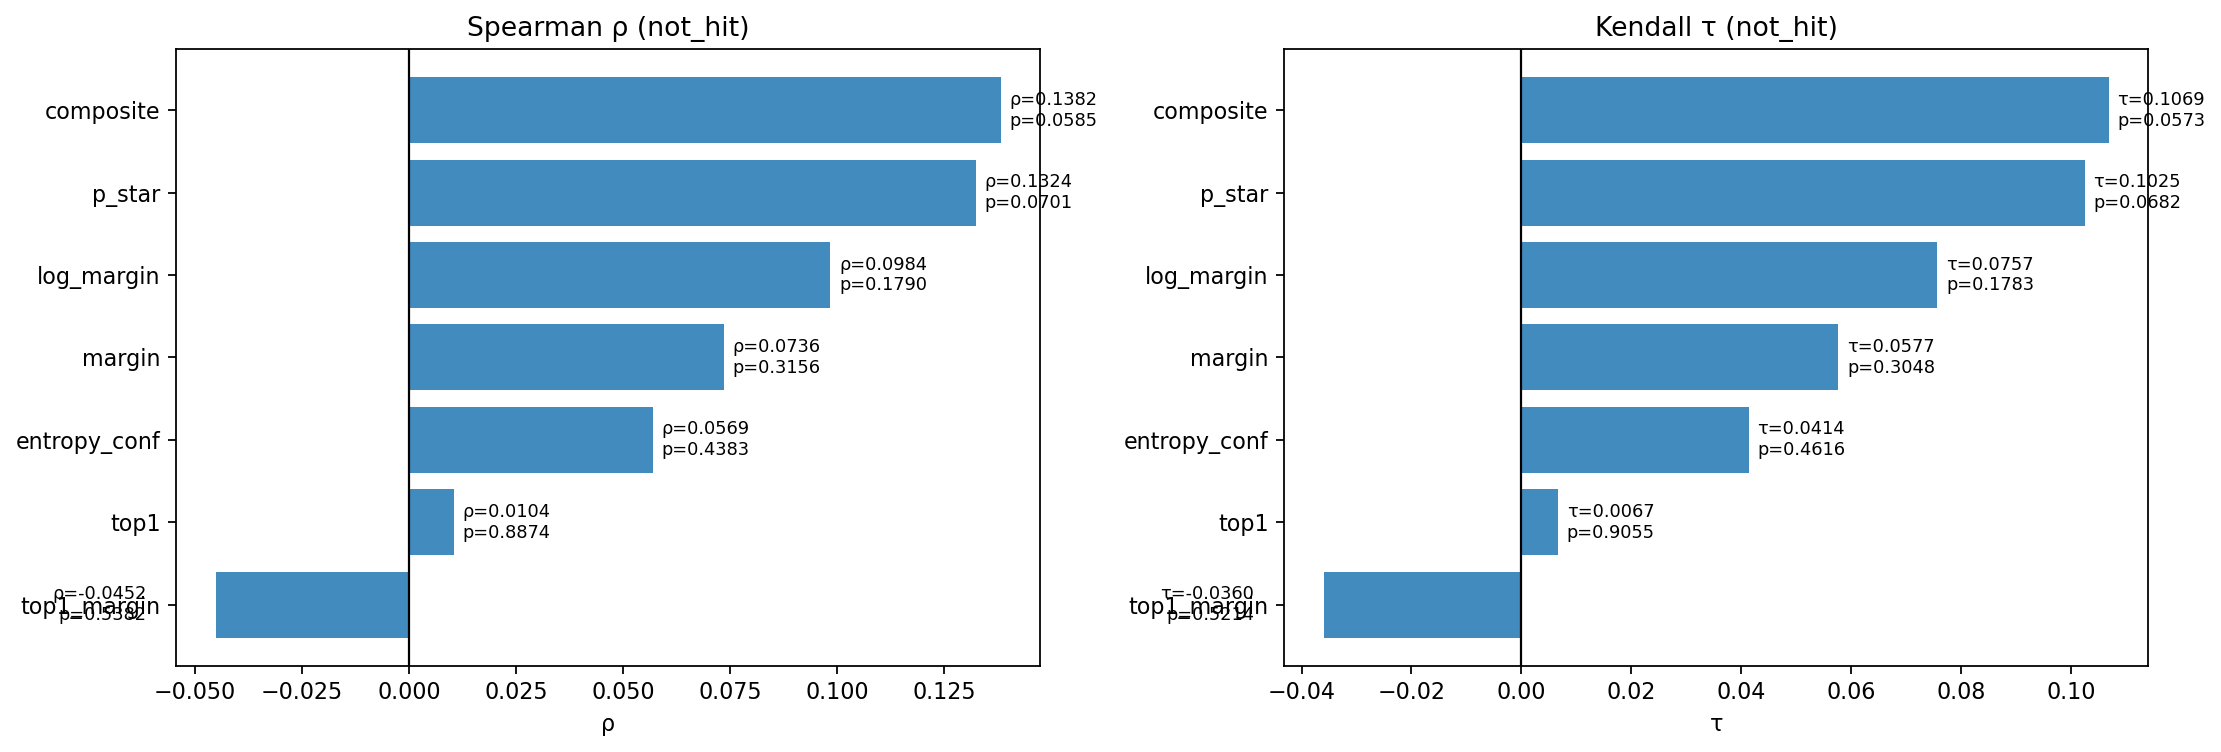

Combined summary table (all / hit / not_hit):


,condition,metric,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,n_trials,rating_levels_used
0,all,p_star,0.2111,0.0001,0.1595,0.0001,0.5962,1.2907,359,"[1, 2, 3, 4, 5]"
1,all,composite,0.2052,0.0001,0.1559,0.0001,0.5940,1.2855,359,"[1, 2, 3, 4, 5]"
2,all,log_margin,0.1899,0.0003,0.1444,0.0003,0.5871,1.2892,359,"[1, 2, 3, 4, 5]"
3,all,margin,0.1842,0.0005,0.1399,0.0005,0.5843,1.2968,359,"[1, 2, 3, 4, 5]"
4,all,entropy_conf,0.1787,0.0007,0.1326,0.0009,0.5800,1.2982,359,"[1, 2, 3, 4, 5]"
5,all,top1,0.1579,0.0027,0.1168,0.0036,0.5704,1.3068,359,"[1, 2, 3, 4, 5]"
6,all,top1_margin,0.1352,0.0103,0.0999,0.0128,0.5602,1.3073,359,"[1, 2, 3, 4, 5]"
7,hit,entropy_conf,0.2738,0.0003,0.1993,0.0006,0.6175,1.3598,171,"[1, 2, 3, 4, 5]"
8,hit,p_star,0.2680,0.0004,0.1959,0.0007,0.6155,1.3697,171,"[1, 2, 3, 4, 5]"
9,hit,top1,0.2680,0.0004,0.1959,0.0007,0.6155,1.3697,171,"[1, 2, 3, 4, 5]"


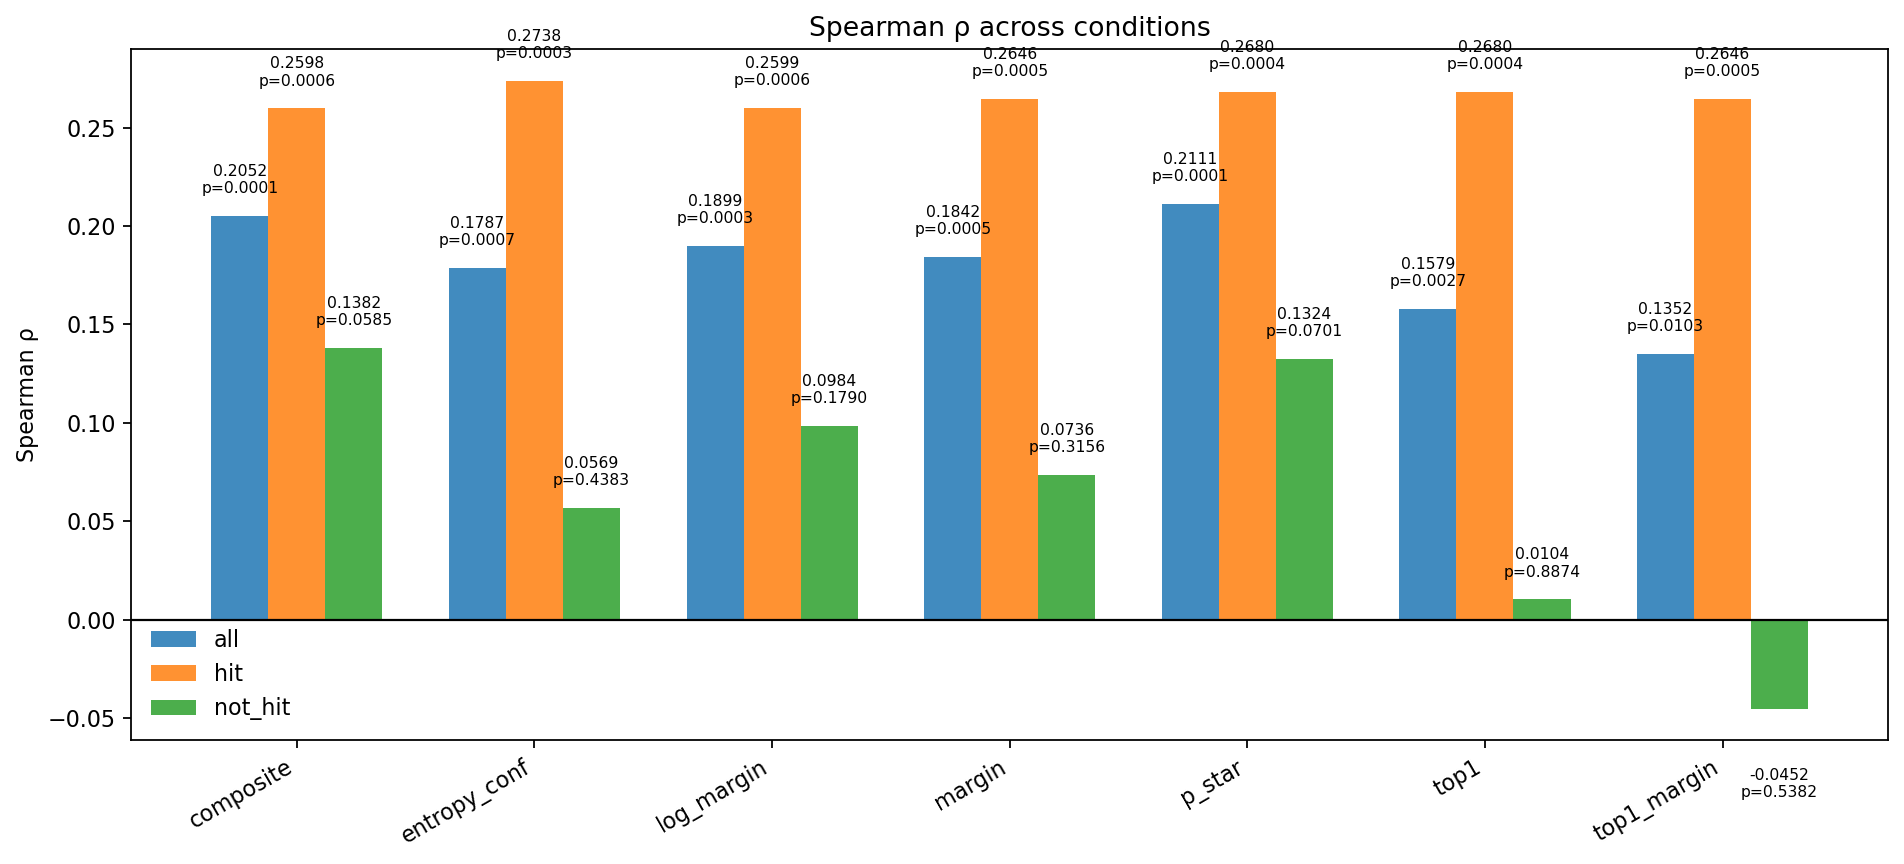

In [21]:
# Cell 2: 在 all / hit / not hit 三种条件下评估 7 个 conf 指标
# 输出相关系数和 p-value 表格，并进行可视化（四位小数，图中标注数值）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from scipy.special import expit
from scipy.optimize import minimize

# 0) 通用函数

def normalize_probs(probs, eps=1e-12):
    probs = np.asarray(probs, dtype=float)
    row_sum = np.clip(probs.sum(axis=1, keepdims=True), eps, None)
    return probs / row_sum

def build_conf_dict(choice, probs, alpha=0.5, eps=1e-12):
    """
    根据 choice 和 probs 计算 7 个 confidence 指标
    choice: 1~4
    probs : (n_trials, 4)
    """
    choice = np.asarray(choice, dtype=int)
    probs = normalize_probs(probs, eps=eps)

    choice0 = choice - 1  # 1-4 -> 0-3
    n = len(choice0)

    p_star = probs[np.arange(n), choice0]

    probs_other = probs.copy()
    probs_other[np.arange(n), choice0] = -np.inf
    p2 = np.clip(np.max(probs_other, axis=1), eps, 1.0)

    margin = p_star - p2
    log_margin = np.log(np.clip(p_star, eps, 1.0)) - np.log(p2)

    top1 = np.max(probs, axis=1)
    sorted_probs = np.sort(probs, axis=1)
    top1_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    p_clip = np.clip(probs, eps, 1.0)
    H = -np.sum(p_clip * np.log(p_clip), axis=1)              # nats
    entropy_conf = 1.0 - H / np.log(probs.shape[1])           # 归一化到[0,1]

    composite = alpha * log_margin + (1 - alpha) * entropy_conf

    conf_dict = {
        "p_star": p_star,
        "log_margin": log_margin,
        "margin": margin,
        "composite": composite,
        "top1": top1,
        "top1_margin": top1_margin,
        "entropy_conf": entropy_conf,
    }
    return conf_dict

def c_index(y, x):
    """
    C-index：随机抽两题，conf 排序与 rating 排序一致的比例（0.5=随机）
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    n = len(y)
    ii, jj = np.triu_indices(n, k=1)
    dy = y[ii] - y[jj]
    dx = x[ii] - x[jj]
    valid = dy != 0
    dy, dx = dy[valid], dx[valid]
    if dy.size == 0:
        return np.nan
    concord = np.sum((dy > 0) & (dx > 0)) + np.sum((dy < 0) & (dx < 0))
    discord = np.sum((dy > 0) & (dx < 0)) + np.sum((dy < 0) & (dx > 0))
    ties = dy.size - concord - discord
    return float((concord + 0.5 * ties) / dy.size)

def _pack_thresholds(theta1, deltas):
    thetas = [theta1]
    cur = theta1
    for d in deltas:
        cur = cur + np.exp(d)   # 保证阈值严格递增
        thetas.append(cur)
    return np.array(thetas)

def ordered_logit_nll(params, x, y, n_classes, eps=1e-12):
    a = params[0]
    theta1 = params[1]
    deltas = params[2:]
    thetas = _pack_thresholds(theta1, deltas)  # length = K-1

    z = a * x
    cdf = expit(thetas[None, :] - z[:, None])  # (n, K-1)

    n = len(x)
    p = np.empty((n, n_classes), dtype=float)
    p[:, 0] = cdf[:, 0]
    for k in range(1, n_classes - 1):
        p[:, k] = cdf[:, k] - cdf[:, k - 1]
    p[:, -1] = 1.0 - cdf[:, -1]
    p = np.clip(p, eps, 1.0)

    idx = y.astype(int) - 1
    return -np.mean(np.log(p[np.arange(n), idx]))

def fit_ordered_logit(x, y, n_classes):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=int)

    qs = np.quantile(x, np.linspace(1/n_classes, (n_classes-1)/n_classes, n_classes-1))
    a0 = 1.0
    thetas0 = qs * a0
    theta1_0 = thetas0[0]
    gaps = np.diff(thetas0)
    gaps = np.clip(gaps, 1e-2, None)
    deltas0 = np.log(gaps)
    p0 = np.concatenate([[a0, theta1_0], deltas0])

    res = minimize(ordered_logit_nll, p0, args=(x, y, n_classes), method="L-BFGS-B")
    return res.x

def cv_ordinal_nll(conf, rating, n_folds=5, seed=0):
    conf = np.asarray(conf, dtype=float)
    rating = np.asarray(rating, dtype=int)

    levels = np.sort(np.unique(rating))
    level_map = {lv: i + 1 for i, lv in enumerate(levels)}
    y = np.array([level_map[r] for r in rating], dtype=int)
    K = len(levels)

    if K < 2:
        return np.nan, [], levels

    n = len(y)
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, min(n_folds, n))

    fold_nlls = []
    for f in range(len(folds)):
        te = folds[f]
        tr = np.concatenate([folds[j] for j in range(len(folds)) if j != f])

        params = fit_ordered_logit(conf[tr], y[tr], n_classes=K)
        nll = ordered_logit_nll(params, conf[te], y[te], n_classes=K)
        fold_nlls.append(float(nll))

    return float(np.mean(fold_nlls)), fold_nlls, levels

def evaluate_conf_metrics(rating, choice, probs, cond_name="all", alpha=0.5, n_folds=5, seed=0):
    """
    在某个条件子集上评估全部 conf 指标
    """
    rating = np.asarray(rating, dtype=float)
    choice = np.asarray(choice, dtype=int)
    probs = np.asarray(probs, dtype=float)

    conf_dict = build_conf_dict(choice, probs, alpha=alpha)

    rows = []
    for name, conf in conf_dict.items():
        conf = np.asarray(conf, dtype=float)

        sp = spearmanr(rating, conf)
        kd = kendalltau(rating, conf)
        ci = c_index(rating, conf)
        nll_mean, nll_folds, used_levels = cv_ordinal_nll(conf, rating, n_folds=n_folds, seed=seed)

        rows.append({
            "condition": cond_name,
            "metric": name,
            "spearman_r": float(sp.correlation),
            "spearman_p": float(sp.pvalue),
            "kendall_tau": float(kd.correlation),
            "kendall_p": float(kd.pvalue),
            "c_index": float(ci),
            "ordinal_nll_cv_mean": float(nll_mean) if np.isfinite(nll_mean) else np.nan,
            "ordinal_nll_cv_folds": nll_folds,
            "rating_levels_used": used_levels.tolist(),
            "n_trials": int(len(rating)),
        })

    res_df = pd.DataFrame(rows).set_index("metric")
    return res_df, conf_dict

def format_result_table(res_df):
    """
    保留四位小数，用于展示
    """
    show_cols = ["spearman_r", "spearman_p", "kendall_tau", "kendall_p", "c_index", "ordinal_nll_cv_mean"]
    res_show = res_df.copy()
    res_show[show_cols] = res_show[show_cols].round(4)
    res_show = res_show.sort_values(["spearman_r", "ordinal_nll_cv_mean"], ascending=[False, True])
    return res_show

def plot_corr_results(res_show, cond_name):
    """
    可视化：
    左图 Spearman rho，标注 rho 和 p
    右图 Kendall tau，标注 tau 和 p
    """
    plot_df = res_show.copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), dpi=160)

    # -----------------------------
    # 左：Spearman rho
    # -----------------------------
    axes[0].barh(plot_df.index, plot_df["spearman_r"], alpha=0.85)
    axes[0].axvline(0, color="k", linewidth=1)
    axes[0].set_title(f"Spearman ρ ({cond_name})")
    axes[0].set_xlabel("ρ")
    axes[0].invert_yaxis()

    x_range0 = axes[0].get_xlim()[1] - axes[0].get_xlim()[0]
    offset0 = x_range0 * 0.01

    for i, m in enumerate(plot_df.index):
        rho = plot_df.loc[m, "spearman_r"]
        p   = plot_df.loc[m, "spearman_p"]
        axes[0].text(
            rho + (offset0 if rho >= 0 else -offset0 * 8),
            i,
            f"ρ={rho:.4f}\np={p:.4f}",
            va="center",
            ha="left" if rho >= 0 else "right",
            fontsize=8
        )

    # -----------------------------
    # 右：Kendall tau
    # -----------------------------
    axes[1].barh(plot_df.index, plot_df["kendall_tau"], alpha=0.85)
    axes[1].axvline(0, color="k", linewidth=1)
    axes[1].set_title(f"Kendall τ ({cond_name})")
    axes[1].set_xlabel("τ")
    axes[1].invert_yaxis()

    x_range1 = axes[1].get_xlim()[1] - axes[1].get_xlim()[0]
    offset1 = x_range1 * 0.01

    for i, m in enumerate(plot_df.index):
        tau = plot_df.loc[m, "kendall_tau"]
        p   = plot_df.loc[m, "kendall_p"]
        axes[1].text(
            tau + (offset1 if tau >= 0 else -offset1 * 8),
            i,
            f"τ={tau:.4f}\np={p:.4f}",
            va="center",
            ha="left" if tau >= 0 else "right",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

def subset_by_condition(rating_c, choice_c, probs_c, hit, cond_name):
    """
    根据条件选择 trial 子集
    """
    if cond_name == "all":
        mask = np.ones(len(hit), dtype=bool)
    elif cond_name == "hit":
        mask = (hit == 1)
    elif cond_name == "not_hit":
        mask = (hit == 0)
    else:
        raise ValueError(f"Unknown condition: {cond_name}")

    rating_sub = np.asarray(rating_c)[mask]
    choice_sub = np.asarray(choice_c)[mask]
    probs_sub  = np.asarray(probs_c)[mask]
    return rating_sub, choice_sub, probs_sub, mask


# 1) 准备条件

conditions = ["all", "hit", "not_hit"]

all_results = {}
all_results_show = {}
summary_rows = []

for cond in conditions:
    rating_sub, choice_sub, probs_sub, mask_sub = subset_by_condition(
        rating_c=rating_c,
        choice_c=choice_c,
        probs_c=probs_c,
        hit=hit,
        cond_name=cond
    )

    print("=" * 70)
    print(f"Condition: {cond}")
    print(f"n_trials: {len(rating_sub)} / {len(rating_c)}")

    res_df, conf_dict = evaluate_conf_metrics(
        rating=rating_sub,
        choice=choice_sub,
        probs=probs_sub,
        cond_name=cond,
        alpha=0.5,
        n_folds=5,
        seed=0
    )

    res_show = format_result_table(res_df)

    all_results[cond] = res_df
    all_results_show[cond] = res_show

    print(f"\nResults for condition = {cond} (rounded to 4 decimals):")
    display(res_show[[
        "condition", "spearman_r", "spearman_p",
        "kendall_tau", "kendall_p",
        "c_index", "ordinal_nll_cv_mean",
        "rating_levels_used", "n_trials"
    ]])

    plot_corr_results(res_show, cond_name=cond)

    # 汇总行
    tmp = res_show.reset_index().copy()
    summary_rows.append(tmp)


# 2) 合并成总表，便于横向比较
summary_df = pd.concat(summary_rows, axis=0, ignore_index=True)

summary_show = summary_df.copy()
round_cols = ["spearman_r", "spearman_p", "kendall_tau", "kendall_p", "c_index", "ordinal_nll_cv_mean"]
summary_show[round_cols] = summary_show[round_cols].round(4)

summary_show = summary_show[[
    "condition", "metric",
    "spearman_r", "spearman_p",
    "kendall_tau", "kendall_p",
    "c_index", "ordinal_nll_cv_mean",
    "n_trials", "rating_levels_used"
]]

print("=" * 70)
print("Combined summary table (all / hit / not_hit):")
display(summary_show.sort_values(["condition", "spearman_r"], ascending=[True, False]))

# 3) 额外做一个总览可视化：不同条件下 Spearman rho 对比

pivot_rho = summary_show.pivot(index="metric", columns="condition", values="spearman_r")
pivot_p   = summary_show.pivot(index="metric", columns="condition", values="spearman_p")

cond_order = ["all", "hit", "not_hit"]
pivot_rho = pivot_rho[[c for c in cond_order if c in pivot_rho.columns]]
pivot_p   = pivot_p[[c for c in cond_order if c in pivot_p.columns]]

x = np.arange(len(pivot_rho.index))
width = 0.24

fig, ax = plt.subplots(figsize=(12, 5.5), dpi=160)

for i, cond in enumerate(pivot_rho.columns):
    vals = pivot_rho[cond].values
    bars = ax.bar(x + (i - 1) * width, vals, width=width, label=cond, alpha=0.85)

    for j, b in enumerate(bars):
        v = vals[j]
        p = pivot_p.loc[pivot_rho.index[j], cond]
        ax.text(
            b.get_x() + b.get_width() / 2,
            v + (0.01 if v >= 0 else -0.03),
            f"{v:.4f}\np={p:.4f}",
            ha="center",
            va="bottom" if v >= 0 else "top",
            fontsize=7
        )

ax.axhline(0, color="k", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(pivot_rho.index, rotation=30, ha="right")
ax.set_ylabel("Spearman ρ")
ax.set_title("Spearman ρ across conditions")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# NEW: choice-constrained posterior

## Cell 1: 数据整理

In [27]:
import numpy as np
import pandas as pd
from IPython.display import display

# Step 1
# 读取当前被试的 prediction 结果，并构造基础 trial-level 分析表
# 这里默认当前 notebook 仍然是单被试分析，因此直接使用 subIDs[0]

subject_id = subIDs[0]
prediction_result = prediction[subject_id]

n_trials_prediction = len(prediction_result['pred_choice'])
assert len(df) >= n_trials_prediction, (
    f"行为数据 df 的行数不足: len(df)={len(df)}, len(prediction)={n_trials_prediction}"
)

# 只保留和 prediction 对齐的部分
behavior_df = df.iloc[:n_trials_prediction].copy().reset_index(drop=True)

# 预测从第2个 trial 开始有效，因此从索引1开始分析
trial_index_array = np.arange(1, n_trials_prediction)
trial_number_array = trial_index_array + 1

true_choice_array = behavior_df.loc[trial_index_array, 'choice'].to_numpy()
predicted_choice_array = np.asarray(prediction_result['pred_choice'])[trial_index_array]

hit_array = (true_choice_array == predicted_choice_array).astype(int)
nonhit_array = 1 - hit_array

# 如果行为表里有 rating，就取出来；否则填 NaN
if 'rating' in behavior_df.columns:
    rating_array = behavior_df.loc[trial_index_array, 'rating'].to_numpy()
else:
    rating_array = np.full(len(trial_index_array), np.nan)

analysis_table = pd.DataFrame({
    'trial': trial_number_array,
    'true_choice': true_choice_array,
    'predicted_choice': predicted_choice_array,
    'hit': hit_array,
    'nonhit': nonhit_array,
    'rating': rating_array,
    'origin_true_choice_probability': np.asarray(
        prediction_result['original_true_choice_prob'], dtype=float
    )[trial_index_array],
    'choice_constrained_true_choice_probability': np.asarray(
        prediction_result['cc_true_choice_prob'], dtype=float
    )[trial_index_array],
    'posterior_shift_tv': np.asarray(
        prediction_result['posterior_shift_tv'], dtype=float
    )[trial_index_array],
    'origin_posterior': [prediction_result['original_posterior'][i] for i in trial_index_array],
    'choice_constrained_posterior': [
        prediction_result['choice_constrained_posterior'][i] for i in trial_index_array
    ]
})

# 标记哪些 trial 真正得到了 choice-constrained posterior
analysis_table['has_choice_constrained_posterior'] = analysis_table[
    'choice_constrained_posterior'
].apply(lambda posterior: isinstance(posterior, dict))

print('Step 1 completed')
print(f'subject_id = {subject_id}')
print(f'n_trials = {len(analysis_table)}')
print(f'n_hit = {int(analysis_table["hit"].sum())}')
print(f'n_nonhit = {int(analysis_table["nonhit"].sum())}')
print(f'n_choice_constrained_available = {int(analysis_table["has_choice_constrained_posterior"].sum())}')

display(analysis_table.head())

Step 1 completed
subject_id = 333
n_trials = 359
n_hit = 171
n_nonhit = 188
n_choice_constrained_available = 188


,trial,true_choice,predicted_choice,hit,nonhit,rating,origin_true_choice_probability,choice_constrained_true_choice_probability,posterior_shift_tv,origin_posterior,choice_constrained_posterior,has_choice_constrained_posterior
0,2,2,3,0,1,1,0.161036,0.242329,0.331354,"{97: 0.07616473678017831, 101: 0.3044374695398...","{97: 0.11826327807990929, 101: 8.2487168629723...",True
1,3,2,1,0,1,1,0.000014,0.000014,0.000000,{80: 1.0},{80: 1.0},True
2,4,3,4,0,1,2,0.216186,0.226121,0.105711,"{80: 8.398239359079381e-06, 68: 1.144265810703...","{80: 9.7099634510276e-06, 68: 8.83410128957925...",True
3,5,2,1,0,1,2,0.237643,0.238865,0.033738,"{80: 0.00010126977842145515, 16: 0.16237531095...","{80: 0.00010654123006828869, 16: 0.17081475729...",True
4,6,4,4,1,0,1,0.302101,NaN,NaN,"{69: 1.7697501348847883e-09, 45: 0.62684132516...",None,False


## Cell 2: 从 posterior 提取指标

In [28]:
# Step 2
# 从 posterior 中提取几个基础指标，便于后续分析

def compute_posterior_entropy(posterior_dict, eps=1e-12):
    if not isinstance(posterior_dict, dict) or len(posterior_dict) == 0:
        return np.nan
    probability_array = np.array(list(posterior_dict.values()), dtype=float)
    probability_array = np.clip(probability_array, eps, 1.0)
    probability_array = probability_array / probability_array.sum()
    return float(-np.sum(probability_array * np.log(probability_array)))

def compute_top1_hypothesis(posterior_dict):
    if not isinstance(posterior_dict, dict) or len(posterior_dict) == 0:
        return np.nan
    return max(posterior_dict, key=posterior_dict.get)

def compute_top1_probability(posterior_dict):
    if not isinstance(posterior_dict, dict) or len(posterior_dict) == 0:
        return np.nan
    return float(max(posterior_dict.values()))

def compute_topk_mass(posterior_dict, k=3):
    if not isinstance(posterior_dict, dict) or len(posterior_dict) == 0:
        return np.nan
    probability_array = np.sort(np.array(list(posterior_dict.values()), dtype=float))[::-1]
    return float(probability_array[:k].sum())

analysis_table['origin_entropy'] = analysis_table['origin_posterior'].apply(compute_posterior_entropy)
analysis_table['choice_constrained_entropy'] = analysis_table[
    'choice_constrained_posterior'
].apply(compute_posterior_entropy)

analysis_table['origin_top1_hypothesis'] = analysis_table['origin_posterior'].apply(compute_top1_hypothesis)
analysis_table['choice_constrained_top1_hypothesis'] = analysis_table[
    'choice_constrained_posterior'
].apply(compute_top1_hypothesis)

analysis_table['origin_top1_probability'] = analysis_table['origin_posterior'].apply(compute_top1_probability)
analysis_table['choice_constrained_top1_probability'] = analysis_table[
    'choice_constrained_posterior'
].apply(compute_top1_probability)

analysis_table['origin_top3_mass'] = analysis_table['origin_posterior'].apply(
    lambda posterior: compute_topk_mass(posterior, k=3)
)
analysis_table['choice_constrained_top3_mass'] = analysis_table[
    'choice_constrained_posterior'
].apply(lambda posterior: compute_topk_mass(posterior, k=3))

# 变化量
analysis_table['delta_true_choice_probability'] = (
    analysis_table['choice_constrained_true_choice_probability']
    - analysis_table['origin_true_choice_probability']
)

analysis_table['delta_entropy'] = (
    analysis_table['choice_constrained_entropy']
    - analysis_table['origin_entropy']
)

analysis_table['top1_hypothesis_changed'] = (
    analysis_table['origin_top1_hypothesis']
    != analysis_table['choice_constrained_top1_hypothesis']
).astype(float)

# 只保留 non-hit 且确实有 choice-constrained posterior 的 trial
nonhit_analysis_table = analysis_table[
    (analysis_table['nonhit'] == 1) &
    (analysis_table['has_choice_constrained_posterior'])
].copy().reset_index(drop=True)

print('Step 2 completed')
print(f'n_nonhit_analysis = {len(nonhit_analysis_table)}')

display(nonhit_analysis_table[[
    'trial',
    'true_choice',
    'predicted_choice',
    'rating',
    'origin_true_choice_probability',
    'choice_constrained_true_choice_probability',
    'delta_true_choice_probability',
    'posterior_shift_tv',
    'origin_entropy',
    'choice_constrained_entropy',
    'delta_entropy',
    'origin_top1_hypothesis',
    'choice_constrained_top1_hypothesis',
    'top1_hypothesis_changed'
]].head(10))

Step 2 completed
n_nonhit_analysis = 188


,trial,true_choice,predicted_choice,rating,origin_true_choice_probability,choice_constrained_true_choice_probability,delta_true_choice_probability,posterior_shift_tv,origin_entropy,choice_constrained_entropy,delta_entropy,origin_top1_hypothesis,choice_constrained_top1_hypothesis,top1_hypothesis_changed
0,2,2,3,1,0.161036,0.242329,8.129298e-02,3.313542e-01,2.142459,2.176542,3.408327e-02,101,107.0,1.0
1,3,2,1,1,0.000014,0.000014,0.000000e+00,0.000000e+00,-0.000000,-0.000000,0.000000e+00,80,80.0,0.0
2,4,3,4,2,0.216186,0.226121,9.935131e-03,1.057110e-01,1.075616,1.098308,2.269129e-02,95,13.0,1.0
3,5,2,1,2,0.237643,0.238865,1.221400e-03,3.373778e-02,1.792788,1.792647,-1.406964e-04,13,16.0,1.0
4,7,2,1,1,0.235822,0.237686,1.864438e-03,4.055688e-02,1.485558,1.522393,3.683426e-02,103,103.0,0.0
5,8,3,2,3,0.249941,0.249941,9.459100e-13,3.134097e-07,0.693371,0.693372,8.379301e-08,30,30.0,0.0
6,11,3,2,3,0.240717,0.240845,1.276260e-04,6.177955e-03,0.602683,0.596833,-5.850234e-03,91,91.0,0.0
7,12,1,4,3,0.124090,0.198365,7.427511e-02,3.764825e-01,1.300409,1.602845,3.024356e-01,91,25.0,1.0
8,14,2,1,1,0.246310,0.246365,5.521613e-05,7.485149e-03,0.693014,0.693147,1.337250e-04,18,18.0,0.0
9,15,3,2,2,0.180855,0.237136,5.628128e-02,2.669724e-01,1.539392,1.566713,2.732064e-02,47,90.0,1.0


## Cell 3: original posterior vs choice-constrained posterior

In [29]:
# Step 3
# 在 non-hit trial 上汇总比较 original posterior 与 choice-constrained posterior 的变化

summary_table = pd.DataFrame({
    'metric': [
        'n_nonhit_trials',
        'mean_origin_true_choice_probability',
        'mean_choice_constrained_true_choice_probability',
        'mean_delta_true_choice_probability',
        'median_delta_true_choice_probability',
        'proportion_delta_true_choice_probability_greater_than_zero',
        'mean_posterior_shift_tv',
        'median_posterior_shift_tv',
        'mean_origin_entropy',
        'mean_choice_constrained_entropy',
        'mean_delta_entropy',
        'proportion_top1_hypothesis_changed'
    ],
    'value': [
        len(nonhit_analysis_table),
        nonhit_analysis_table['origin_true_choice_probability'].mean(),
        nonhit_analysis_table['choice_constrained_true_choice_probability'].mean(),
        nonhit_analysis_table['delta_true_choice_probability'].mean(),
        nonhit_analysis_table['delta_true_choice_probability'].median(),
        (nonhit_analysis_table['delta_true_choice_probability'] > 0).mean(),
        nonhit_analysis_table['posterior_shift_tv'].mean(),
        nonhit_analysis_table['posterior_shift_tv'].median(),
        nonhit_analysis_table['origin_entropy'].mean(),
        nonhit_analysis_table['choice_constrained_entropy'].mean(),
        nonhit_analysis_table['delta_entropy'].mean(),
        nonhit_analysis_table['top1_hypothesis_changed'].mean()
    ]
})

summary_table['value'] = summary_table['value'].astype(float).round(6)

print('Step 3 completed')
display(summary_table)

# 如果有 rating，则顺便按 rating 做一个均值汇总，便于后续继续分析 confidence
if np.isfinite(nonhit_analysis_table['rating']).any():
    rating_summary_table = (
        nonhit_analysis_table
        .groupby('rating')[[
            'origin_true_choice_probability',
            'choice_constrained_true_choice_probability',
            'delta_true_choice_probability',
            'posterior_shift_tv',
            'origin_entropy',
            'choice_constrained_entropy',
            'delta_entropy'
        ]]
        .mean()
        .round(4)
        .reset_index()
    )

    print('Rating-wise summary')
    display(rating_summary_table)

Step 3 completed


,metric,value
0,n_nonhit_trials,188.000000
1,mean_origin_true_choice_probability,0.169753
2,mean_choice_constrained_true_choice_probability,0.212835
3,mean_delta_true_choice_probability,0.043082
4,median_delta_true_choice_probability,0.013684
5,proportion_delta_true_choice_probability_great...,0.994681
6,mean_posterior_shift_tv,0.177713
7,median_posterior_shift_tv,0.092011
8,mean_origin_entropy,0.804190
9,mean_choice_constrained_entropy,0.995367


Rating-wise summary


,rating,origin_true_choice_probability,choice_constrained_true_choice_probability,delta_true_choice_probability,posterior_shift_tv,origin_entropy,choice_constrained_entropy,delta_entropy
0,1,0.1522,0.1912,0.0389,0.1971,0.8817,1.0723,0.1905
1,2,0.1709,0.2027,0.0319,0.1654,0.8586,1.0596,0.2010
2,3,0.1775,0.2709,0.0934,0.2106,0.5918,0.8048,0.2130
3,4,0.2204,0.3041,0.0837,0.1503,0.2887,0.4628,0.1741
4,5,0.2681,0.2715,0.0034,0.0282,0.6915,0.6784,-0.0130


## Cell 4: 可视化 original vs choice-constrained

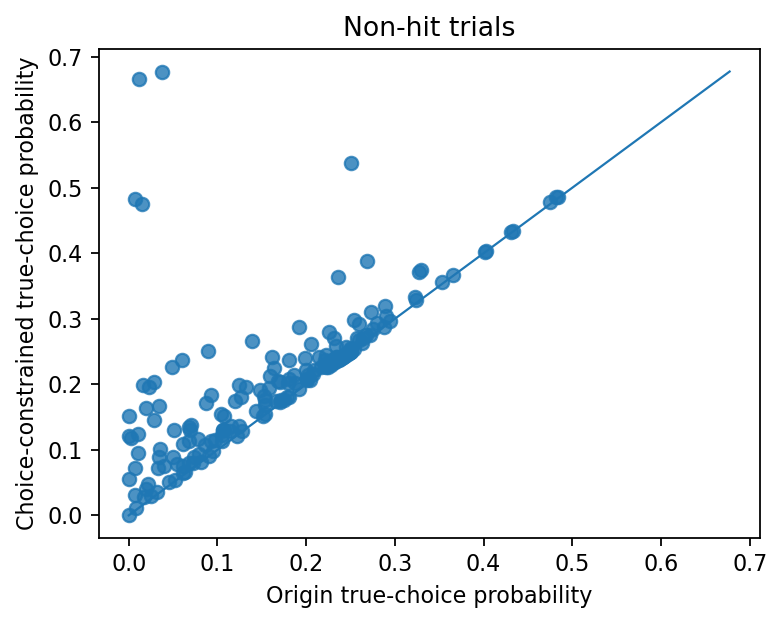

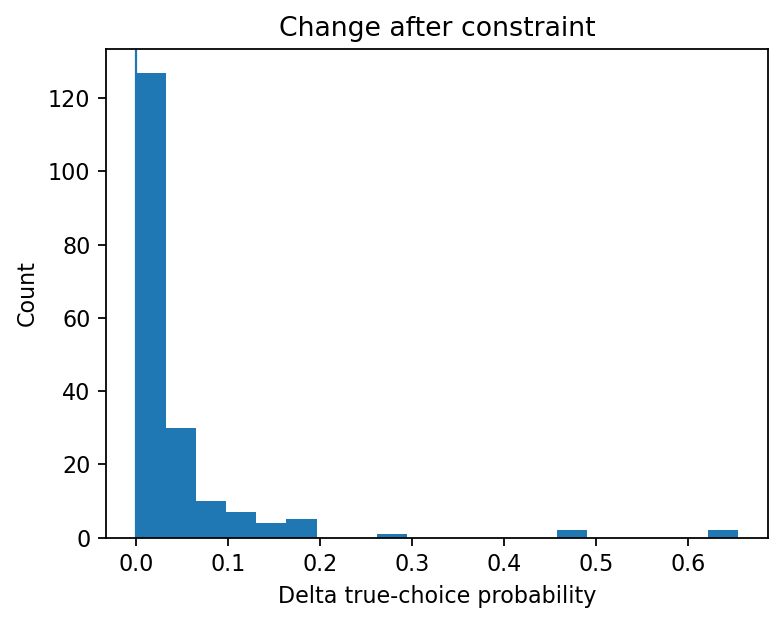

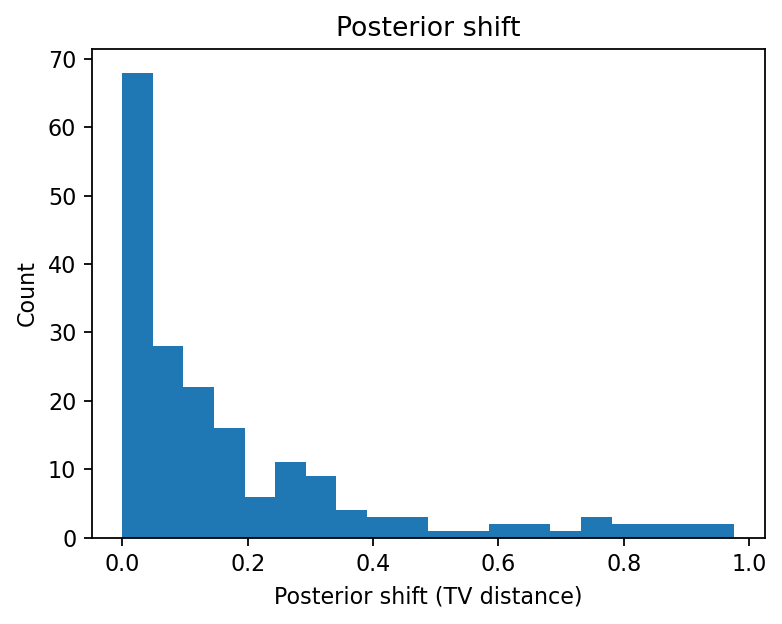

In [31]:
# Step 4
# 可视化展示 non-hit trial 上的变化

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4), dpi=160)
plt.scatter(
    nonhit_analysis_table['origin_true_choice_probability'],
    nonhit_analysis_table['choice_constrained_true_choice_probability'],
    alpha=0.8
)
min_value = min(
    nonhit_analysis_table['origin_true_choice_probability'].min(),
    nonhit_analysis_table['choice_constrained_true_choice_probability'].min()
)
max_value = max(
    nonhit_analysis_table['origin_true_choice_probability'].max(),
    nonhit_analysis_table['choice_constrained_true_choice_probability'].max()
)
plt.plot([min_value, max_value], [min_value, max_value], linewidth=1)
plt.xlabel('Origin true-choice probability')
plt.ylabel('Choice-constrained true-choice probability')
plt.title('Non-hit trials')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4), dpi=160)
plt.hist(nonhit_analysis_table['delta_true_choice_probability'].dropna(), bins=20)
plt.axvline(0, linewidth=1)
plt.xlabel('Delta true-choice probability')
plt.ylabel('Count')
plt.title('Change after constraint')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4), dpi=160)
plt.hist(nonhit_analysis_table['posterior_shift_tv'].dropna(), bins=20)
plt.xlabel('Posterior shift (TV distance)')
plt.ylabel('Count')
plt.title('Posterior shift')
plt.tight_layout()
plt.show()

## Confidence / rating analysis on non-hit trials

目标：
1. 检查被试的 rating 是否与 posterior 指标存在系统关系  
2. 比较 original posterior 和 choice-constrained posterior，看看哪一个更贴近被试的主观状态  
3. 用相关分析和按 rating 分组可视化来展示结果

In [37]:
# Step 5
# 构造用于 confidence / rating 分析的指标表
# 这里只使用 non-hit trial，因为 choice-constrained posterior 只在这些 trial 上定义

rating_analysis_table = nonhit_analysis_table.copy()

# 为了更好解释，再补充几个方向更直观的量
# entropy 越低表示越集中，因此这里额外构造“entropy_reduction”
rating_analysis_table['entropy_reduction'] = (
    rating_analysis_table['origin_entropy']
    - rating_analysis_table['choice_constrained_entropy']
)

# 也可以构造“certainty gain”
rating_analysis_table['true_choice_probability_gain'] = (
    rating_analysis_table['choice_constrained_true_choice_probability']
    - rating_analysis_table['origin_true_choice_probability']
)

# 用于展示的核心列
rating_analysis_core_columns = [
    'trial',
    'rating',
    'true_choice',
    'predicted_choice',
    'origin_true_choice_probability',
    'choice_constrained_true_choice_probability',
    'true_choice_probability_gain',
    'origin_entropy',
    'choice_constrained_entropy',
    'entropy_reduction',
    'posterior_shift_tv'
]

print('Step 5 completed')
print(f'n_nonhit_trials_for_rating_analysis = {len(rating_analysis_table)}')

display(rating_analysis_table[rating_analysis_core_columns].head(10))

Step 5 completed
n_nonhit_trials_for_rating_analysis = 188


,trial,rating,true_choice,predicted_choice,origin_true_choice_probability,choice_constrained_true_choice_probability,true_choice_probability_gain,origin_entropy,choice_constrained_entropy,entropy_reduction,posterior_shift_tv
0,2,1,2,3,0.161036,0.242329,8.129298e-02,2.142459,2.176542,-3.408327e-02,3.313542e-01
1,3,1,2,1,0.000014,0.000014,0.000000e+00,-0.000000,-0.000000,0.000000e+00,0.000000e+00
2,4,2,3,4,0.216186,0.226121,9.935131e-03,1.075616,1.098308,-2.269129e-02,1.057110e-01
3,5,2,2,1,0.237643,0.238865,1.221400e-03,1.792788,1.792647,1.406964e-04,3.373778e-02
4,7,1,2,1,0.235822,0.237686,1.864438e-03,1.485558,1.522393,-3.683426e-02,4.055688e-02
5,8,3,3,2,0.249941,0.249941,9.459100e-13,0.693371,0.693372,-8.379301e-08,3.134097e-07
6,11,3,3,2,0.240717,0.240845,1.276260e-04,0.602683,0.596833,5.850234e-03,6.177955e-03
7,12,3,1,4,0.124090,0.198365,7.427511e-02,1.300409,1.602845,-3.024356e-01,3.764825e-01
8,14,1,2,1,0.246310,0.246365,5.521613e-05,0.693014,0.693147,-1.337250e-04,7.485149e-03
9,15,2,3,2,0.180855,0.237136,5.628128e-02,1.539392,1.566713,-2.732064e-02,2.669724e-01


In [38]:
# Step 6
# 计算 rating 与各个 posterior 指标之间的相关
# 兼容不同 scipy 版本下 spearmanr / pearsonr 的返回格式

from scipy.stats import spearmanr, pearsonr

def extract_correlation_and_pvalue(result):
    """
    兼容不同 scipy 版本的相关检验返回对象
    支持：
    1. 新版本对象：result.statistic / result.pvalue
    2. 一些版本对象：result.correlation / result.pvalue
    3. 更旧版本 tuple: (correlation, pvalue)
    """
    if hasattr(result, 'statistic') and hasattr(result, 'pvalue'):
        return float(result.statistic), float(result.pvalue)

    if hasattr(result, 'correlation') and hasattr(result, 'pvalue'):
        return float(result.correlation), float(result.pvalue)

    if isinstance(result, (tuple, list)) and len(result) >= 2:
        return float(result[0]), float(result[1])

    raise ValueError(f'无法解析相关分析返回结果: {type(result)}')

def compute_correlation_table(dataframe, rating_column, metric_columns):
    correlation_results = []

    for metric_name in metric_columns:
        valid_df = dataframe[[rating_column, metric_name]].dropna().copy()

        if len(valid_df) < 3:
            correlation_results.append({
                'metric': metric_name,
                'n': len(valid_df),
                'spearman_rho': np.nan,
                'spearman_p': np.nan,
                'pearson_r': np.nan,
                'pearson_p': np.nan
            })
            continue

        spearman_result = spearmanr(valid_df[rating_column], valid_df[metric_name])
        pearson_result = pearsonr(valid_df[rating_column], valid_df[metric_name])

        spearman_rho, spearman_p = extract_correlation_and_pvalue(spearman_result)
        pearson_r, pearson_p = extract_correlation_and_pvalue(pearson_result)

        correlation_results.append({
            'metric': metric_name,
            'n': len(valid_df),
            'spearman_rho': spearman_rho,
            'spearman_p': spearman_p,
            'pearson_r': pearson_r,
            'pearson_p': pearson_p
        })

    correlation_table = pd.DataFrame(correlation_results)
    return correlation_table

metric_columns_for_rating = [
    'origin_true_choice_probability',
    'choice_constrained_true_choice_probability',
    'true_choice_probability_gain',
    'origin_entropy',
    'choice_constrained_entropy',
    'entropy_reduction',
    'posterior_shift_tv'
]

rating_correlation_table = compute_correlation_table(
    dataframe=rating_analysis_table,
    rating_column='rating',
    metric_columns=metric_columns_for_rating
)

def interpret_metric_direction(metric_name):
    if metric_name in [
        'origin_true_choice_probability',
        'choice_constrained_true_choice_probability',
        'true_choice_probability_gain',
        'entropy_reduction'
    ]:
        return 'positive_expected'
    if metric_name in [
        'origin_entropy',
        'choice_constrained_entropy'
    ]:
        return 'negative_expected'
    return 'exploratory'

rating_correlation_table['expected_direction'] = rating_correlation_table['metric'].apply(
    interpret_metric_direction
)

rating_correlation_table = rating_correlation_table[[
    'metric',
    'expected_direction',
    'n',
    'spearman_rho',
    'spearman_p',
    'pearson_r',
    'pearson_p'
]].sort_values(by='spearman_rho', ascending=False)

print('Step 6 completed')
display(rating_correlation_table)

origin_rating_rho = rating_correlation_table.loc[
    rating_correlation_table['metric'] == 'origin_true_choice_probability',
    'spearman_rho'
].iloc[0]

choice_constrained_rating_rho = rating_correlation_table.loc[
    rating_correlation_table['metric'] == 'choice_constrained_true_choice_probability',
    'spearman_rho'
].iloc[0]

print('Key comparison')
print(f'Spearman rho: rating ~ origin_true_choice_probability = {origin_rating_rho:.4f}')
print(f'Spearman rho: rating ~ choice_constrained_true_choice_probability = {choice_constrained_rating_rho:.4f}')
print(f'Difference (choice-constrained - origin) = {choice_constrained_rating_rho - origin_rating_rho:.4f}')

Step 6 completed


,metric,expected_direction,n,spearman_rho,spearman_p,pearson_r,pearson_p
1,choice_constrained_true_choice_probability,positive_expected,188,0.190315,0.008896,0.271219,0.000167
0,origin_true_choice_probability,positive_expected,188,0.132402,0.070098,0.201552,0.005543
5,entropy_reduction,positive_expected,188,0.024798,0.735512,0.045012,0.539631
2,true_choice_probability_gain,positive_expected,188,-0.095989,0.190064,0.093586,0.201447
6,posterior_shift_tv,exploratory,188,-0.134433,0.065869,-0.086719,0.236676
3,origin_entropy,negative_expected,188,-0.173583,0.017206,-0.199254,0.006119
4,choice_constrained_entropy,negative_expected,188,-0.193102,0.007929,-0.229457,0.001537


Key comparison
Spearman rho: rating ~ origin_true_choice_probability = 0.1324
Spearman rho: rating ~ choice_constrained_true_choice_probability = 0.1903
Difference (choice-constrained - origin) = 0.0579


In [39]:
# Step 7
# 按 rating 水平做均值汇总，便于直观观察单调趋势

rating_group_summary_table = (
    rating_analysis_table
    .groupby('rating')[[
        'origin_true_choice_probability',
        'choice_constrained_true_choice_probability',
        'true_choice_probability_gain',
        'origin_entropy',
        'choice_constrained_entropy',
        'entropy_reduction',
        'posterior_shift_tv'
    ]]
    .agg(['mean', 'std', 'count'])
)

# 展平列名
rating_group_summary_table.columns = [
    f'{metric}_{statistic}'
    for metric, statistic in rating_group_summary_table.columns
]
rating_group_summary_table = rating_group_summary_table.reset_index()

# 补充标准误
for metric_name in [
    'origin_true_choice_probability',
    'choice_constrained_true_choice_probability',
    'true_choice_probability_gain',
    'origin_entropy',
    'choice_constrained_entropy',
    'entropy_reduction',
    'posterior_shift_tv'
]:
    mean_column = f'{metric_name}_mean'
    std_column = f'{metric_name}_std'
    count_column = f'{metric_name}_count'
    sem_column = f'{metric_name}_sem'

    rating_group_summary_table[sem_column] = (
        rating_group_summary_table[std_column]
        / np.sqrt(rating_group_summary_table[count_column])
    )

print('Step 7 completed')
display(rating_group_summary_table)

Step 7 completed


,rating,origin_true_choice_probability_mean,origin_true_choice_probability_std,origin_true_choice_probability_count,choice_constrained_true_choice_probability_mean,choice_constrained_true_choice_probability_std,choice_constrained_true_choice_probability_count,true_choice_probability_gain_mean,true_choice_probability_gain_std,true_choice_probability_gain_count,...,posterior_shift_tv_mean,posterior_shift_tv_std,posterior_shift_tv_count,origin_true_choice_probability_sem,choice_constrained_true_choice_probability_sem,true_choice_probability_gain_sem,origin_entropy_sem,choice_constrained_entropy_sem,entropy_reduction_sem,posterior_shift_tv_sem
0,1,0.152231,0.088487,71,0.191150,0.090344,71,0.038919,0.051919,71,...,0.197120,0.221161,71,0.010501,0.010722,0.006162,0.070850,0.067337,0.041362,0.026247
1,2,0.170872,0.102742,82,0.202744,0.086587,82,0.031872,0.046687,82,...,0.165354,0.207769,82,0.011346,0.009562,0.005156,0.070609,0.070302,0.042785,0.022944
2,3,0.177451,0.127264,20,0.270898,0.154470,20,0.093447,0.192752,20,...,0.210568,0.301852,20,0.028457,0.034541,0.043101,0.105552,0.101587,0.081814,0.067496
3,4,0.220435,0.160439,10,0.304104,0.195287,10,0.083669,0.197615,10,...,0.150331,0.248882,10,0.050735,0.061755,0.062491,0.059967,0.093826,0.087516,0.078703
4,5,0.268057,0.149361,5,0.271458,0.149811,5,0.003401,0.003056,5,...,0.028153,0.018693,5,0.066796,0.066997,0.001367,0.259025,0.257421,0.024965,0.008360


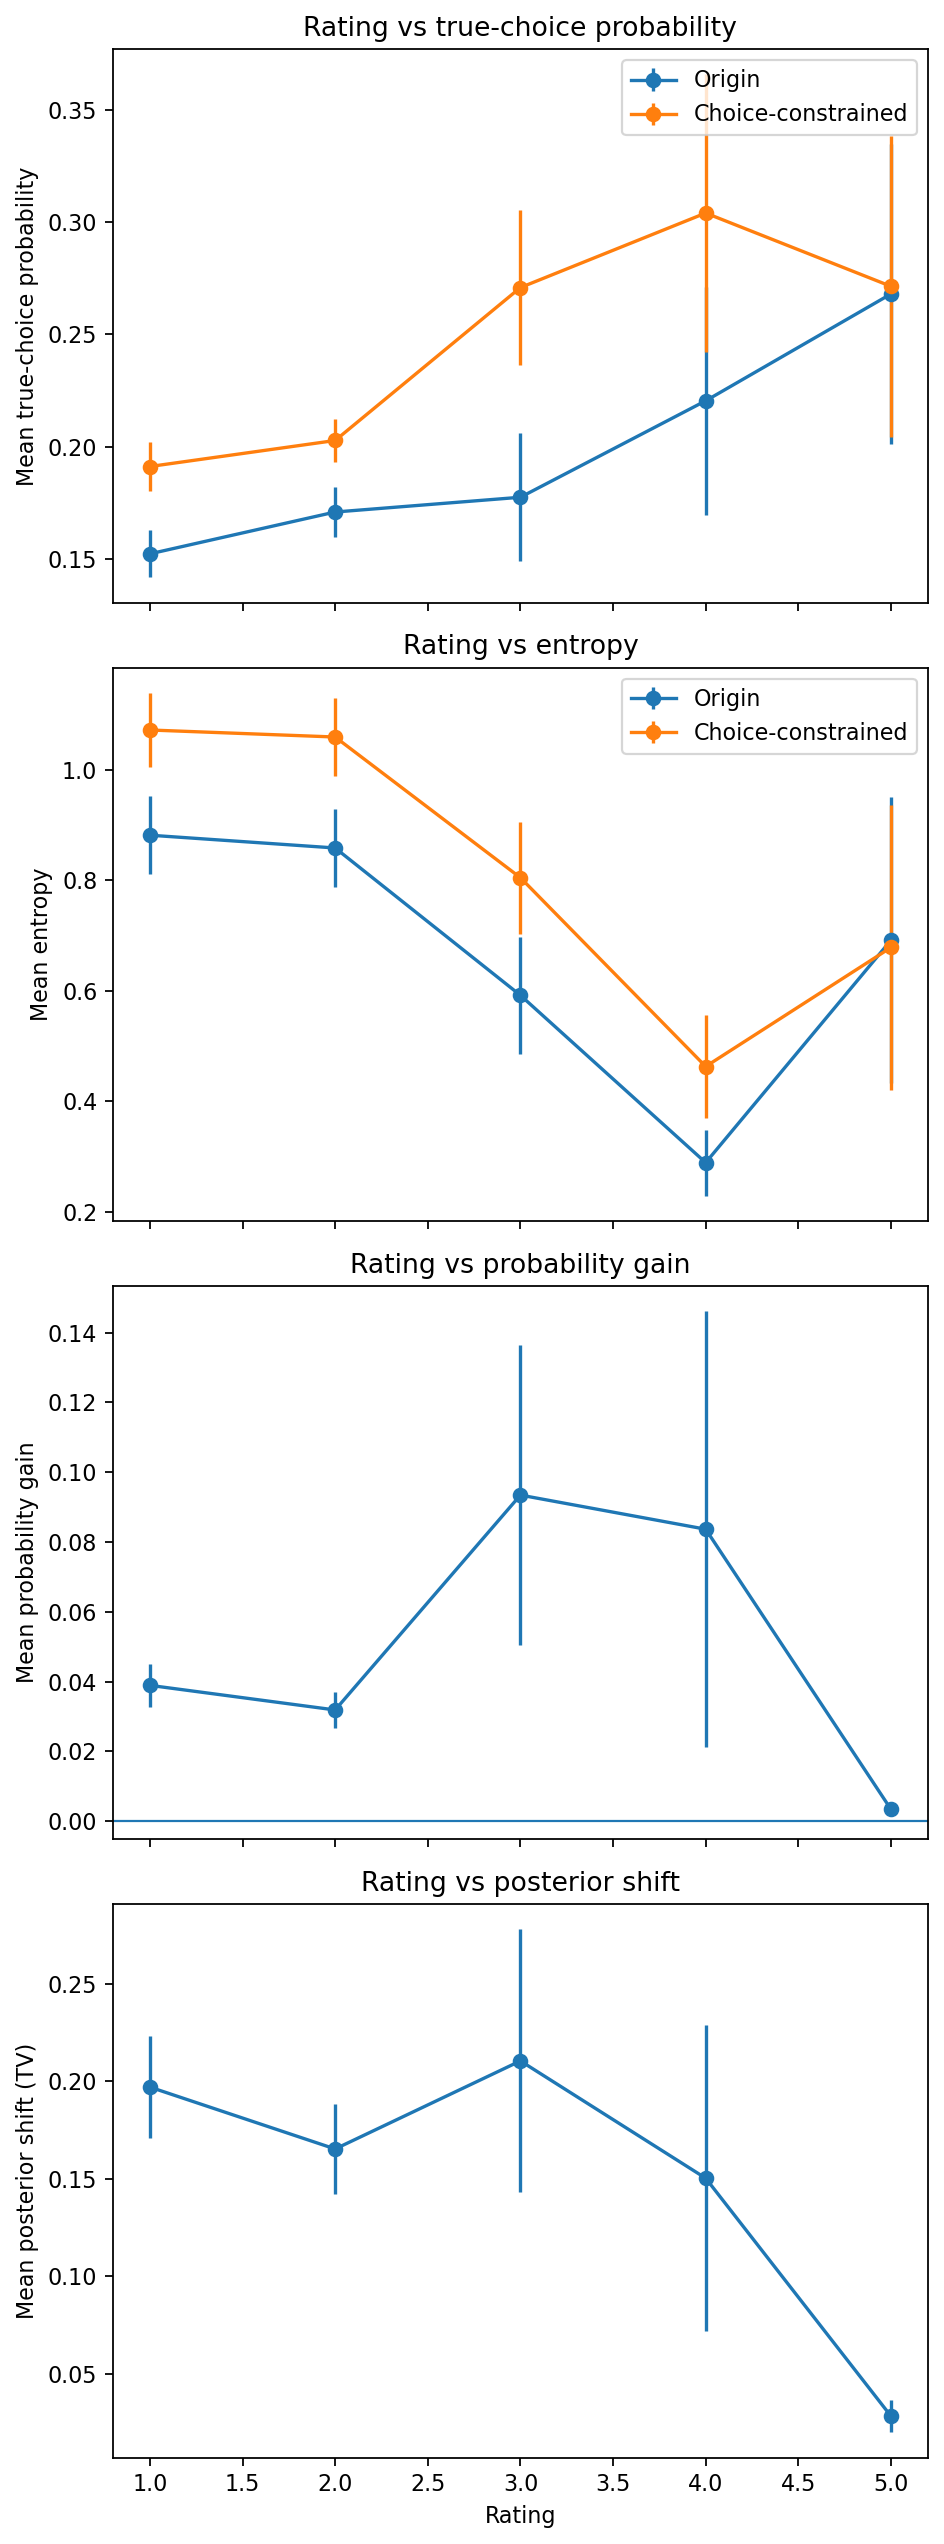

In [42]:
# Step 8
# 将 rating 相关的可视化放在一张图中，竖排展示

import matplotlib.pyplot as plt

rating_values = rating_group_summary_table['rating'].to_numpy()

fig, axes = plt.subplots(4, 1, figsize=(6, 16), dpi=160, sharex=True)

# 8.1 rating vs true-choice probability
axes[0].errorbar(
    rating_values,
    rating_group_summary_table['origin_true_choice_probability_mean'],
    yerr=rating_group_summary_table['origin_true_choice_probability_sem'],
    marker='o',
    label='Origin'
)
axes[0].errorbar(
    rating_values,
    rating_group_summary_table['choice_constrained_true_choice_probability_mean'],
    yerr=rating_group_summary_table['choice_constrained_true_choice_probability_sem'],
    marker='o',
    label='Choice-constrained'
)
axes[0].set_ylabel('Mean true-choice probability')
axes[0].set_title('Rating vs true-choice probability')
axes[0].legend()

# 8.2 rating vs entropy
axes[1].errorbar(
    rating_values,
    rating_group_summary_table['origin_entropy_mean'],
    yerr=rating_group_summary_table['origin_entropy_sem'],
    marker='o',
    label='Origin'
)
axes[1].errorbar(
    rating_values,
    rating_group_summary_table['choice_constrained_entropy_mean'],
    yerr=rating_group_summary_table['choice_constrained_entropy_sem'],
    marker='o',
    label='Choice-constrained'
)
axes[1].set_ylabel('Mean entropy')
axes[1].set_title('Rating vs entropy')
axes[1].legend()

# 8.3 rating vs probability gain
axes[2].errorbar(
    rating_values,
    rating_group_summary_table['true_choice_probability_gain_mean'],
    yerr=rating_group_summary_table['true_choice_probability_gain_sem'],
    marker='o'
)
axes[2].axhline(0, linewidth=1)
axes[2].set_ylabel('Mean probability gain')
axes[2].set_title('Rating vs probability gain')

# 8.4 rating vs posterior shift
axes[3].errorbar(
    rating_values,
    rating_group_summary_table['posterior_shift_tv_mean'],
    yerr=rating_group_summary_table['posterior_shift_tv_sem'],
    marker='o'
)
axes[3].set_xlabel('Rating')
axes[3].set_ylabel('Mean posterior shift (TV)')
axes[3].set_title('Rating vs posterior shift')

plt.tight_layout()
plt.show()

# ------

2026-03-24 18:19:06 - INFO - Posterior Probabilities for k by Subject saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260322/M6_MH_post.png


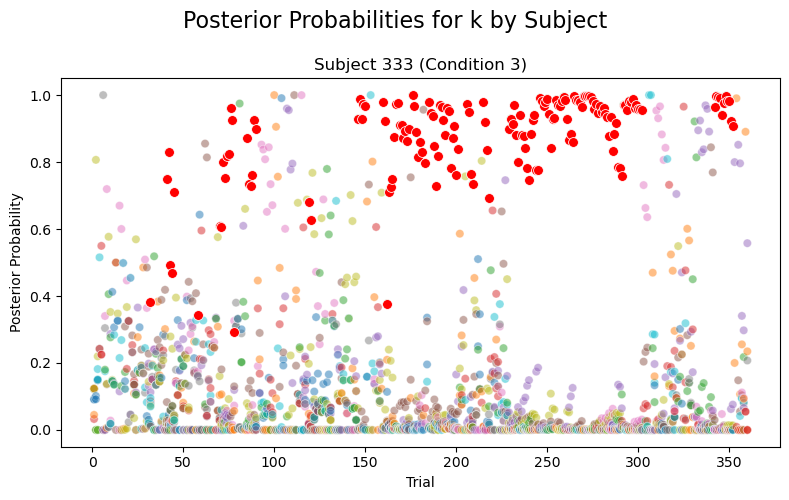

In [10]:
# plot posterior probabilities
model_eval = ModelEval()
model_eval.plot_posterior_probabilities(
    res, save_path=result_path/f'{model_name}_post.png')

2026-03-24 18:19:07 - INFO - Grid Search Error by Subject saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260322/M6_MH_grid.png
2026-03-24 18:19:07 - INFO - Strategy Amount by Subject saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260322/M6_MH_amount.png


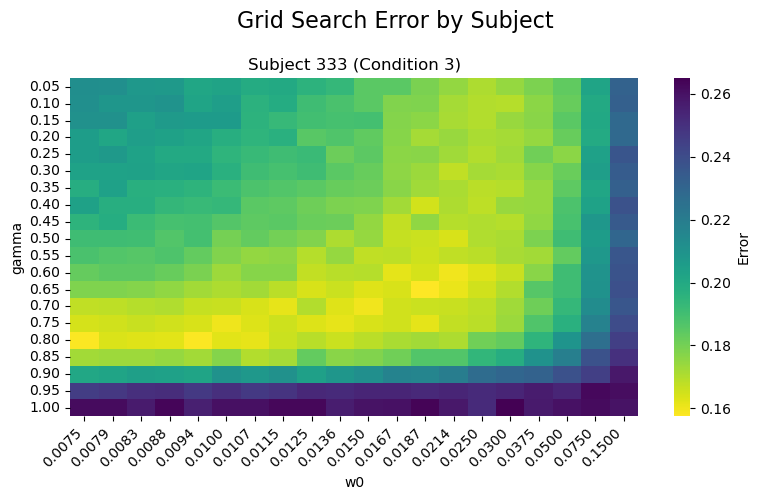

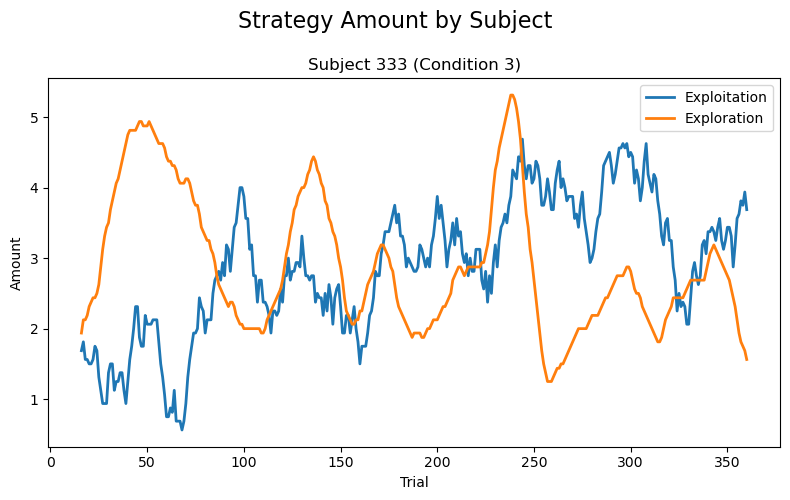

In [11]:
# plot gamma and w0 grids
if model_name in ['M2_M', 'M4_PM', 'M6_MH', 'M7_PMH']:
    model_eval.plot_error_grids(res, fname=['gamma','w0'], save_path=result_path/f'{model_name}_grid.png')

# plot strategy amount dynamics
if model_name in ['M3_H', 'M5_PH', 'M6_MH', 'M7_PMH']:
    model_eval.plot_cluster_amount(res, window_size=16, save_path=result_path/f'{model_name}_amount.png')

2026-03-24 18:19:07 - INFO - Predicted vs True Accuracy by Subject saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260322/M6_MH_acc.png


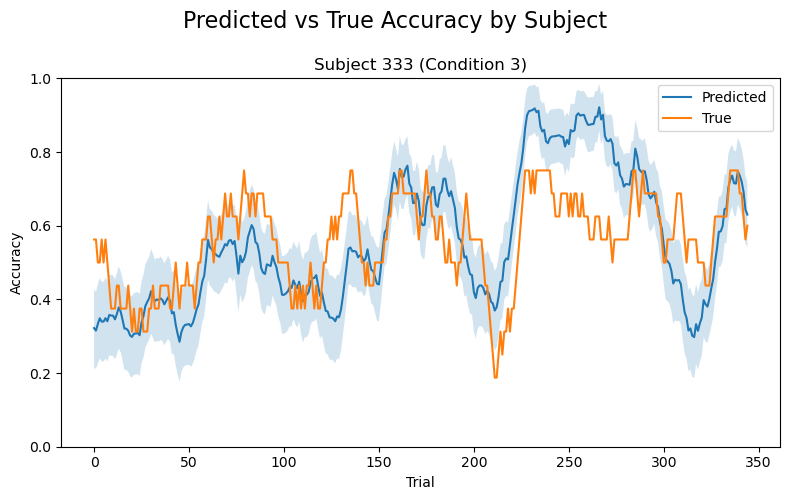

In [12]:
# plot accuracy comparison
model_eval.plot_accuracy_comparison(prediction, save_path=result_path/f'{model_name}_acc.png')